In [1]:
import json
import h5py

In [2]:
!ls -l src/data/shapenetpart_hdf5_2048/

total 676508
-rwxrwxrwx 1 harkhymadhe harkhymadhe 83904512 Jan 20  2020 test0.h5
-rwxrwxrwx 1 harkhymadhe harkhymadhe   114437 Jan 17  2020 test0_id2file.json
-rwxrwxrwx 1 harkhymadhe harkhymadhe    19084 Jan 17  2020 test0_id2name.json
-rwxrwxrwx 1 harkhymadhe harkhymadhe 33841616 Jan 20  2020 test1.h5
-rwxrwxrwx 1 harkhymadhe harkhymadhe    46145 Jan 17  2020 test1_id2file.json
-rwxrwxrwx 1 harkhymadhe harkhymadhe     7776 Jan 17  2020 test1_id2name.json
-rwxrwxrwx 1 harkhymadhe harkhymadhe 83904512 Jan 20  2020 train0.h5
-rwxrwxrwx 1 harkhymadhe harkhymadhe   114410 Jan 17  2020 train0_id2file.json
-rwxrwxrwx 1 harkhymadhe harkhymadhe    19287 Jan 17  2020 train0_id2name.json
-rwxrwxrwx 1 harkhymadhe harkhymadhe 83904512 Jan 20  2020 train1.h5
-rwxrwxrwx 1 harkhymadhe harkhymadhe   114434 Jan 17  2020 train1_id2file.json
-rwxrwxrwx 1 harkhymadhe harkhymadhe    19326 Jan 17  2020 train1_id2name.json
-rwxrwxrwx 1 harkhymadhe harkhymadhe 83904512 Jan 20  2020 train2.h5
-rwxrwxrwx 1 har

In [3]:
fpath = "src/data/shapenetpart_hdf5_2048/train0.h5"
label_fpath = "src/data/shapenetpart_hdf5_2048/train0_id2name.json"

In [4]:
file = h5py.File(fpath)

In [5]:
file.keys()

<KeysViewHDF5 ['data', 'label', 'seg']>

In [6]:
file["seg"].shape

(2048, 2048)

In [15]:
file["label"].shape

(2048, 1)

In [7]:
file["data"].shape[0] * 6

12288

In [8]:
file["data"][0]

array([[-0.7347337 ,  0.03068223,  0.03131984],
       [ 0.99903065, -0.04045135, -0.01736243],
       [-0.16596751,  0.01770532, -0.76737696],
       ...,
       [-0.0845532 ,  0.00762618,  0.5760725 ],
       [ 0.20081264, -0.0669595 , -0.0213185 ],
       [-0.8385741 ,  0.05177284,  0.00695351]],
      shape=(2048, 3), dtype=float32)

In [9]:
from sparse_bregman.utils import display_point_cloud

/home/harkhymadhe/miniforge3/envs/bregman/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


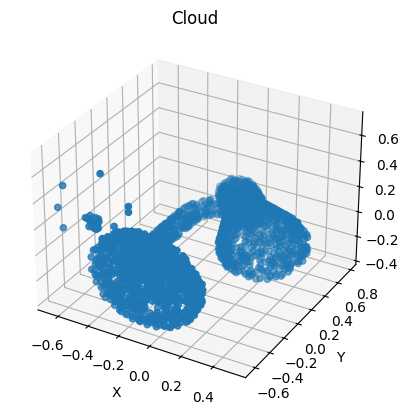

In [10]:
display_point_cloud(file["data"][40], title = "Cloud")

In [11]:
with open(label_fpath, "r") as f:
    label_dict = json.load(f)

In [12]:
len(label_dict)

2048

In [13]:
label_dict

['airplane',
 'lamp',
 'table',
 'airplane',
 'lamp',
 'chair',
 'table',
 'pistol',
 'table',
 'airplane',
 'chair',
 'car',
 'guitar',
 'laptop',
 'chair',
 'chair',
 'table',
 'chair',
 'rocket',
 'chair',
 'guitar',
 'car',
 'motorbike',
 'airplane',
 'table',
 'airplane',
 'chair',
 'airplane',
 'airplane',
 'car',
 'cap',
 'lamp',
 'knife',
 'airplane',
 'chair',
 'motorbike',
 'lamp',
 'chair',
 'knife',
 'airplane',
 'lamp',
 'chair',
 'pistol',
 'laptop',
 'car',
 'pistol',
 'car',
 'chair',
 'table',
 'airplane',
 'lamp',
 'chair',
 'laptop',
 'table',
 'pistol',
 'chair',
 'chair',
 'table',
 'chair',
 'table',
 'chair',
 'chair',
 'table',
 'lamp',
 'chair',
 'skateboard',
 'airplane',
 'chair',
 'skateboard',
 'airplane',
 'chair',
 'laptop',
 'lamp',
 'lamp',
 'lamp',
 'chair',
 'chair',
 'airplane',
 'airplane',
 'table',
 'chair',
 'airplane',
 'chair',
 'chair',
 'laptop',
 'chair',
 'airplane',
 'table',
 'lamp',
 'table',
 'car',
 'chair',
 'chair',
 'table',
 'table

In [ ]:
import numpy as np

In [ ]:
pattern = "src/data/shapenetpart_hdf5_2048/train{}.h5"
files = []

for i in range(6):
    path = pattern.format(i)
    f = h5py.File(path)
    print(f["data"].shape)
    files.append(f["data"])

num_train = sum(e.shape[0] for e in files)

In [ ]:
data = np.concatenate(files, axis = 0)

In [ ]:
data.shape

In [ ]:
test_pattern = "src/data/shapenetpart_hdf5_2048/test{}.h5"
test_files = []

for i in range(2):
    path = test_pattern.format(i)
    f = h5py.File(path)
    print(f["data"].shape)
    test_files.append(f["data"])

num_test = sum(e.shape[0] for e in test_files)

In [ ]:
val_pattern = "src/data/shapenetpart_hdf5_2048/test{}.h5"
val_files = []

for i in range(2):
    path = val_pattern.format(i)
    f = h5py.File(path)
    print(f["data"].shape)
    val_files.append(f["data"])

num_val = sum(e.shape[0] for e in val_files)

In [ ]:
num_train + num_test + num_val

In [ ]:
4e6 / num_train